# K-Nearest Neighbor Regression and Classification Example

**Predicting Movie Preferences and Ratings Using KNN**

Goal:

Simulate a movie recommendation scenario using KNN.

- Classification: Predict if a user will like a movie (like / dislike)

- Regression: Predict the rating a user would give a movie (1–5)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Simulate User-Movie Dataset

In [13]:
# Simulated dataset: 100 users, 5 movie features
np.random.seed(42)

data = pd.DataFrame({
    'user_age': np.random.randint(15, 60, 100),
    'user_experience': np.random.randint(1, 10, 100),  # years watching movies
    'movie_action_score': np.random.randint(1, 10, 100),
    'movie_comedy_score': np.random.randint(1, 10, 100),
    'movie_drama_score': np.random.randint(1, 10, 100),
})

data

,user_age,user_experience,movie_action_score,movie_comedy_score,movie_drama_score
0,53,8,2,8,1
1,43,3,6,1,5
2,29,3,6,5,7
3,57,1,1,3,6
4,22,5,9,1,5
...,...,...,...,...,...
95,58,1,5,4,5
96,22,6,6,5,3
97,38,8,3,5,7
98,25,5,9,7,2


## 3. Encoding Target Variables

In [14]:
# Classification target: Like (1) / Dislike (0)
data['like'] = ((data['movie_action_score'] + data['user_experience']) % 2 == 0).astype(int)

# Regression target: Rating (1-5)
data['rating'] = ((data['movie_comedy_score'] + data['movie_drama_score']) / 4 + np.random.rand(100)*2).clip(1,5)

## 4. Split Dataset

In [8]:
features = ['user_age', 'user_experience', 'movie_action_score', 'movie_comedy_score', 'movie_drama_score']

X = data[features]

# Classification
y_class = data['like']

# Regression
y_reg = data['rating']

# Train/test split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42) #Splitting into 80% Train and 20% Test

## 5. Scale Features

In [9]:
# StandardScaler standardizes features to have mean=0 and std=1
# This puts all features on the same scale, so each feature contributes equally.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data
X_test_scaled = scaler.transform(X_test)        # transform test data using same scaler

KNN relies on distance between points (Euclidean by default), so features with larger scales can dominate the distance calculation.

For example, 'user_age' (15–60) could outweigh 'movie scores' (1–10) if we don’t normalize the data.

## 6. KNN Classification

In [5]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_class_train)

y_class_pred = knn_clf.predict(X_test_scaled)
print("Classification Accuracy:", accuracy_score(y_class_test, y_class_pred))

Classification Accuracy: 0.65


## 7. KNN Regression

In [11]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_reg_train)

y_reg_pred = knn_reg.predict(X_test_scaled)
print("Regression MSE:", mean_squared_error(y_reg_test, y_reg_pred))

Regression MSE: 0.44872745047005036


## 8. Visualize Results

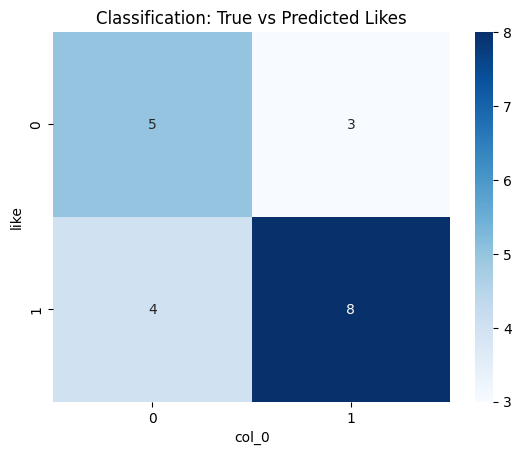

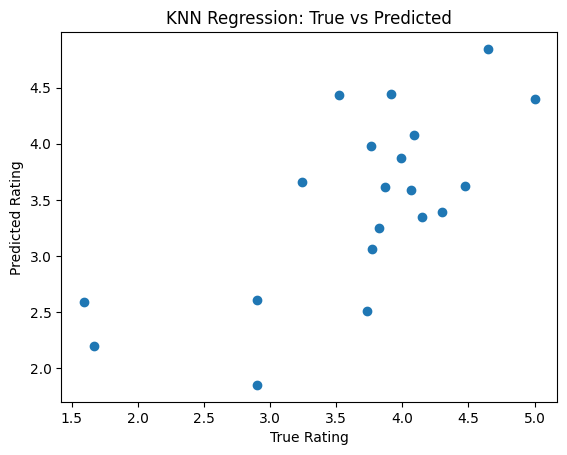

In [12]:
# Classification confusion
sns.heatmap(pd.crosstab(y_class_test, y_class_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Classification: True vs Predicted Likes")
plt.show()

# Regression scatter
plt.scatter(y_reg_test, y_reg_pred)
plt.xlabel("True Rating")
plt.ylabel("Predicted Rating")
plt.title("KNN Regression: True vs Predicted")
plt.show()

# Take aways

- KNN can be used for both classification and regression.

- Model performance depends heavily on K and feature scaling.

- Standardization is essential for distance-based models.

- KNN is intuitive and effective as a baseline model.